In [2]:
import tifffile as tf
import numpy as np
import matplotlib.pyplot as plt
import os

These will be off by one sample because matlabs save-out adds a blank end sample

In [3]:
fname = r"E:\L6 Experiments\L609-pan\FOV4\SD1_odor_day4_FOV4_optoRec_LBC0\SD1_odor_day4_FOV4_optoRec_LBC0_img_001"
img_matlab = tf.memmap(os.path.join(fname, 'img.tif'), mode='r')
img_python = tf.memmap(os.path.join(fname,'img_test.tif'), mode='r')
print("Matlab shape:",img_matlab.shape)
print("Python shape:",img_python.shape)

Matlab shape: (15751, 512, 512)
Python shape: (15750, 512, 512)


Text(0.5, 1.0, 'Matlab')

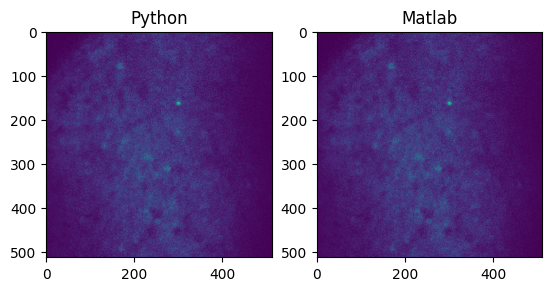

In [7]:
fig, ax = plt.subplots(nrows=1,ncols=2)
ax[0].imshow(img_python[0]); ax[0].set_title("Python")
ax[1].imshow(img_matlab[0]); ax[1].set_title("Matlab")

Take the difference between matrices

In [8]:
# getting a max projection
max_python = np.max(img_python, axis=0)
max_matlab = np.max(img_matlab, axis=0)

Text(0.5, 1.0, 'Max Python - Max Matlab')

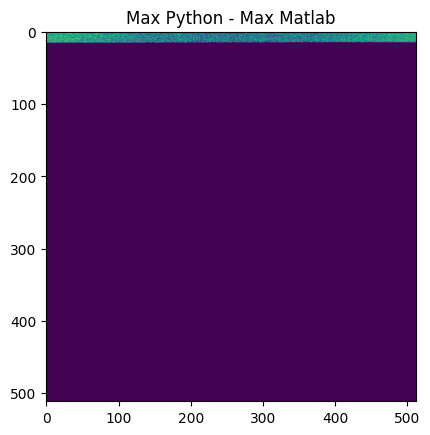

In [9]:
plt.imshow(max_python-max_matlab)
plt.title("Max Python - Max Matlab")

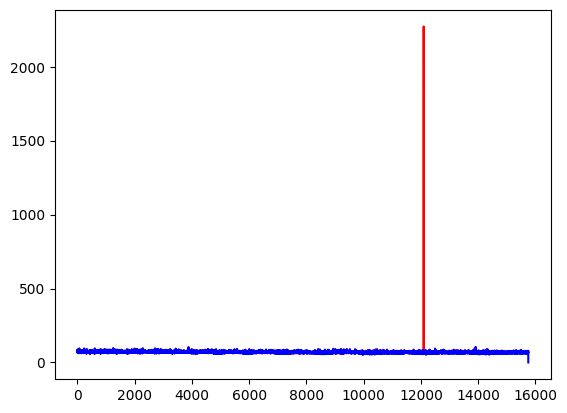

In [11]:
plt.plot(img_python[:,0,0], color = 'r')
plt.plot(img_matlab[:,0,0], color='b')

Weird conversion issue

In [1]:
import os; import matplotlib.pyplot as plt; import tifffile as tf
path_added = os.path.split(os.path.split(os.getcwd())[0])[0]; os.chdir(path_added); print("Added path:",path_added)
import thorfuns

Added path: c:\Users\spell\SpellmanLab Dropbox\timspellman\Python\John\PySpell\code


In [2]:
# max_proj didn't solve high memory demands, testing why my file is weird when converting with matlab
# slow
fname = r"F:\John\L6 Experiments\recordings_panneuronal\L6-02\sessions\SD1_whisker_d1\img\Image_001_001.raw"
thorfuns.RawToTif(filepath=fname).convert(method='max_proj')

Starting at 18.0 <%> RAM utility
rootpath: F:\John\L6 Experiments\recordings_panneuronal\L6-02\sessions\SD1_whisker_d1\img
This code does not support multi-channel recordings
Starting at 18.0 <%> RAM utility
method: max_proj detected. Your file will be saved with dimensions (t,y,x): 60000 512 512
Please wait while memory mapped file is created...


c:\Users\spell\anaconda3\envs\suite2p\lib\site-packages\tifffile\tifffile.py:3607: UserWarning: <tifffile.TiffWriter 'img_mmap_maxproj_z.tif'> truncating ImageJ file
  warnings.warn(


4.640625
Update: 18.0 <%> RAM utility
Run time for 0 / 60000 : 53.4375 Memory: 18.2 <%> RAM utility
Run time for 500 / 60000 : 54.5625 Memory: 18.3 <%> RAM utility
Run time for 1000 / 60000 : 56.0 Memory: 18.5 <%> RAM utility
Run time for 1500 / 60000 : 57.296875 Memory: 18.6 <%> RAM utility
Run time for 2000 / 60000 : 58.5625 Memory: 18.8 <%> RAM utility
Run time for 2500 / 60000 : 59.78125 Memory: 18.9 <%> RAM utility
Run time for 3000 / 60000 : 61.015625 Memory: 19.0 <%> RAM utility
Run time for 3500 / 60000 : 62.1875 Memory: 19.2 <%> RAM utility
Run time for 4000 / 60000 : 63.46875 Memory: 19.3 <%> RAM utility
Run time for 4500 / 60000 : 64.71875 Memory: 19.5 <%> RAM utility
Run time for 5000 / 60000 : 65.8125 Memory: 19.6 <%> RAM utility
Run time for 5500 / 60000 : 66.953125 Memory: 19.8 <%> RAM utility
Run time for 6000 / 60000 : 68.1875 Memory: 19.9 <%> RAM utility
Run time for 6500 / 60000 : 69.390625 Memory: 20.1 <%> RAM utility
Run time for 7000 / 60000 : 70.765625 Memory: 20

In [3]:
img = tf.memmap(r"F:\John\L6 Experiments\recordings_panneuronal\L6-02\sessions\SD1_whisker_d1\img\img_mmap_maxproj_z.tif")
img.shape

(60000, 512, 512)

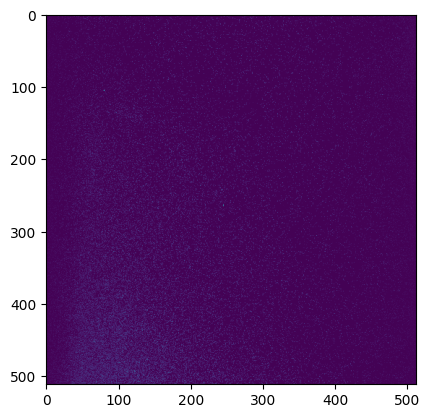

In [9]:
plt.imshow(img[2])